## 1. Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv(r"C:\Users\Student\Downloads\archive (2)\Housing.csv")
print("The Shape:", df.shape)
df.head()


The Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

We check for:
- Missing values
- Duplicate rows
- Inconsistent categorical labels
- Outliers / impossible values (e.g. price or area <= 0)

In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_report[missing_report['missing_count'] > 0] if missing.sum() > 0 else "No missing values found.")


No missing values found.


In [7]:
# Duplicate rows
dupe_count = df.duplicated().sum()
print(f"Duplicate rows: {dupe_count}")
if dupe_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)


Duplicate rows: 0


In [8]:
# Standardize categorical text (strip whitespace, lowercase for consistency checks)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()
    print(c, '->', df[c].unique())


Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
mainroad -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
guestroom -> <StringArray>
['no', 'yes']
Length: 2, dtype: str
basement -> <StringArray>
['no', 'yes']
Length: 2, dtype: str
hotwaterheating -> <StringArray>
['no', 'yes']
Length: 2, dtype: str
airconditioning -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
prefarea -> <StringArray>
['yes', 'no']
Length: 2, dtype: str
furnishingstatus -> <StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


C:\Users\Student\AppData\Local\Temp\ipykernel_14512\2649560341.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [10]:
# Sanity checks: no non-positive price/area, valid bed/bath counts
sanity_issues = df[(df['price'] <= 0) | (df['area'] <= 0) | (df['bedrooms'] <= 0) | (df['bathrooms'] <= 0)]
print(f"Rows with impossible values: {len(sanity_issues)}")
sanity_issues


Rows with impossible values: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


In [11]:
# Outlier check via IQR on price and area (flag, don't blindly drop)
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for col in ['price', 'area']:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: {n_out} potential outliers outside [{low:.0f}, {high:.0f}]")


price: 15 potential outliers outside [-35000, 9205000]
area: 12 potential outliers outside [-540, 10500]


**Note:** This dataset has no missing values and no duplicate rows. A small number of high-end properties sit above the IQR upper bound for `price` and `area` — these are kept since they reflect genuine luxury listings, not data errors. If building a predictive model, consider log-transforming `price`/`area` or using robust/tree-based models less sensitive to these outliers.

In [12]:
# Encode binary yes/no columns for correlation analysis later
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df_encoded = df.copy()
for c in binary_cols:
    df_encoded[c] = df_encoded[c].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
df_encoded = pd.get_dummies(df_encoded, columns=['furnishingstatus'], drop_first=False)

df_encoded.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [14]:
# Save cleaned dataset
df.to_csv('Housing_cleaned.csv', index=False)
df_encoded.to_csv('Housing_cleaned_encoded.csv', index=False)
print("Saved: Housing_cleaned.csv (cleaned, original categories) and Housing_cleaned_encoded.csv (numeric/encoded for modeling)")


Saved: Housing_cleaned.csv (cleaned, original categories) and Housing_cleaned_encoded.csv (numeric/encoded for modeling)


## 3. Univariate Analysis

Distribution of individual variables — numeric and categorical.

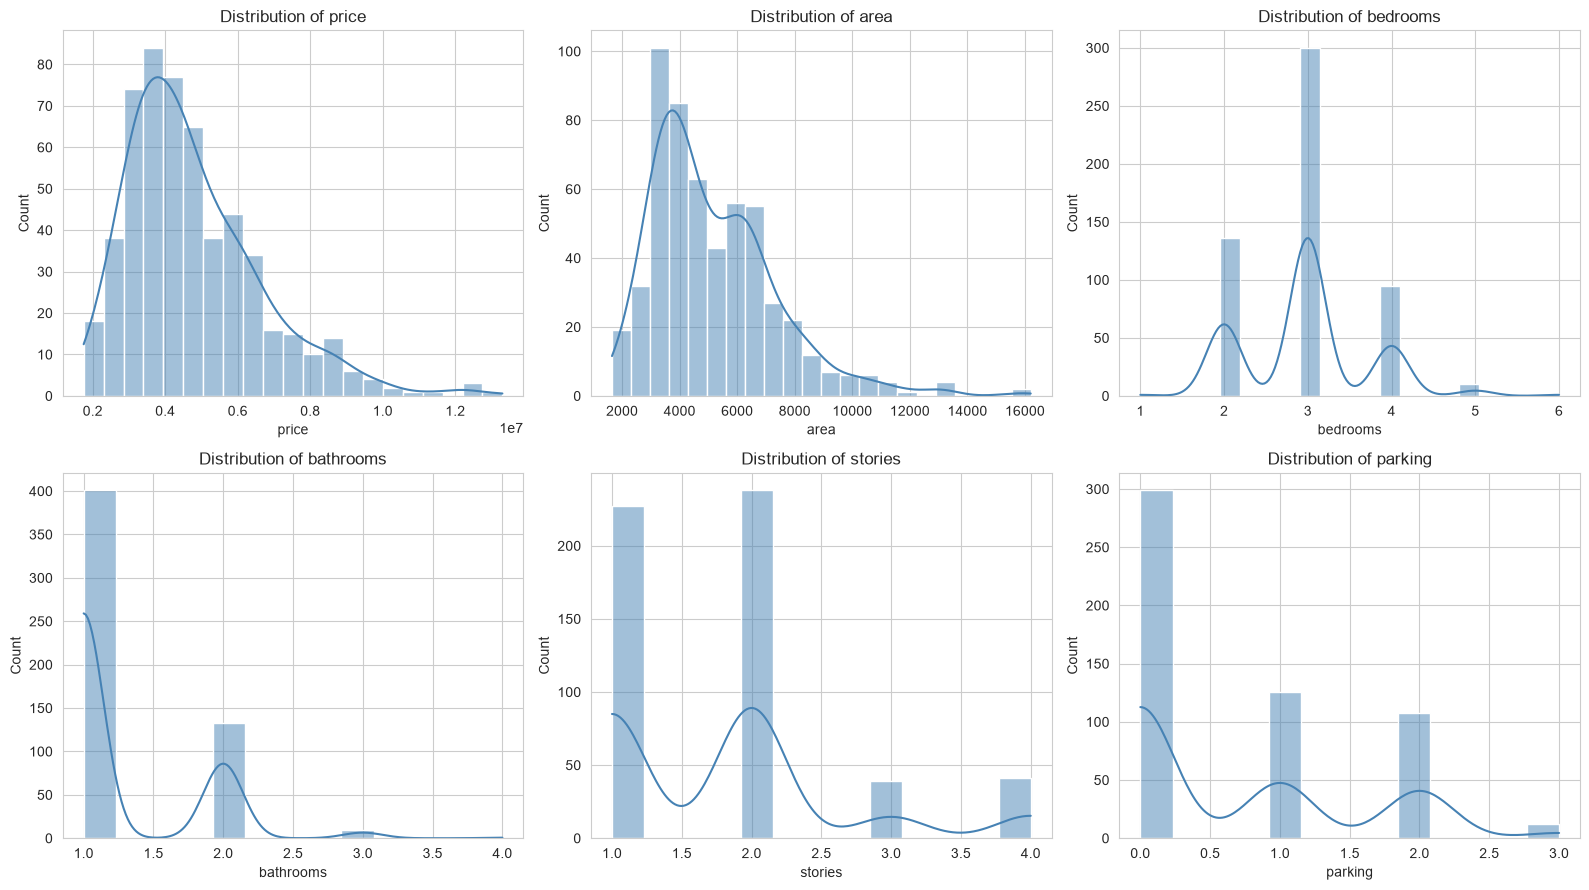

In [16]:
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('univariate_histograms.png', dpi=120)
plt.show()


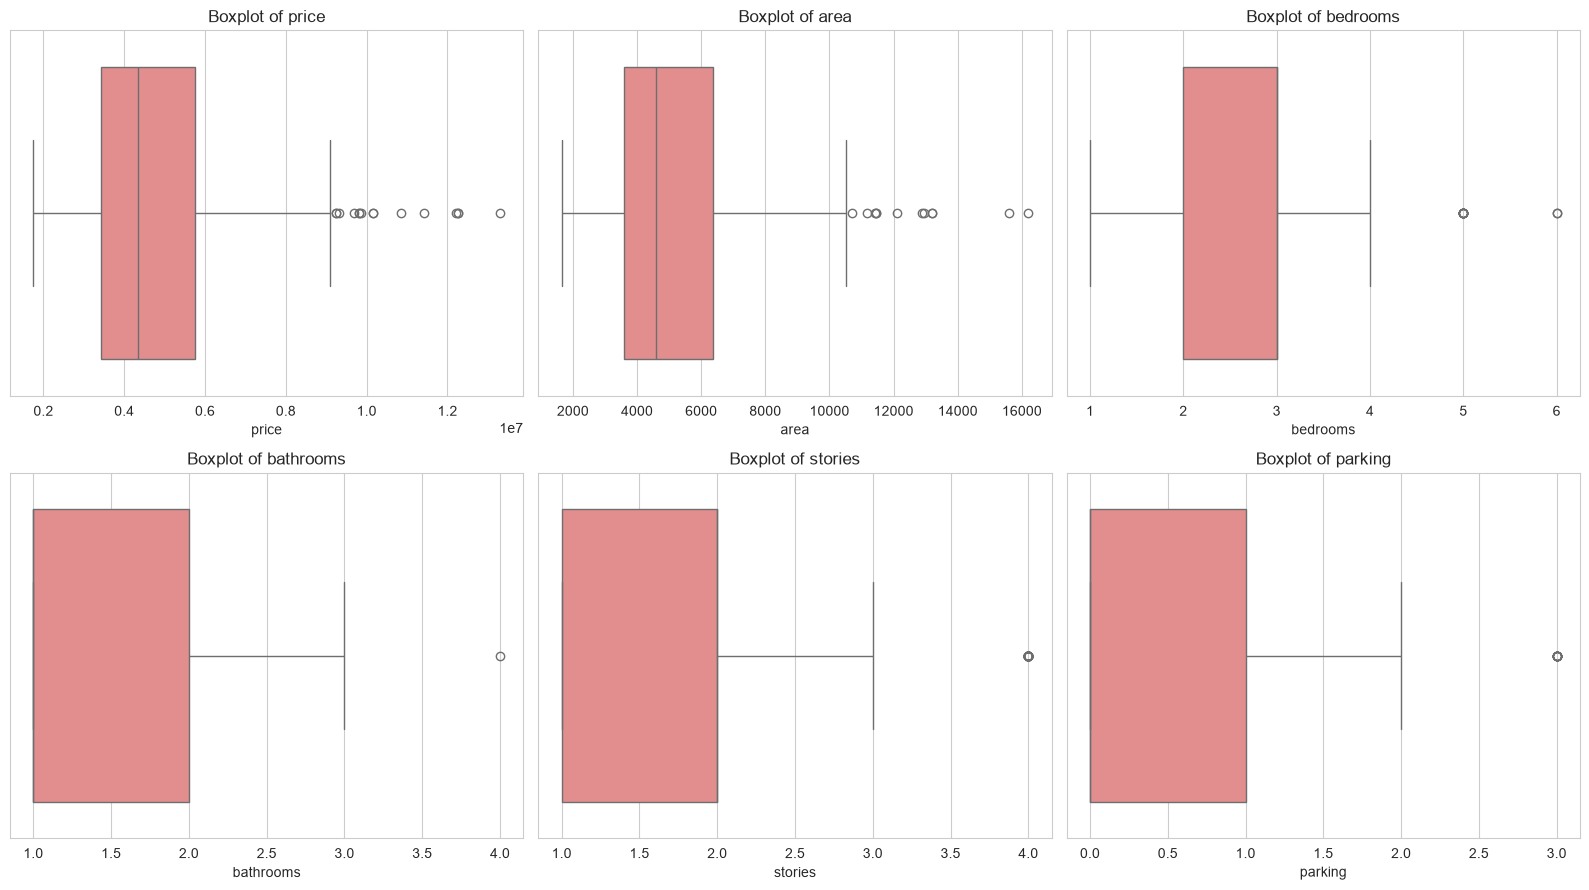

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('univariate_boxplots.png', dpi=120)
plt.show()


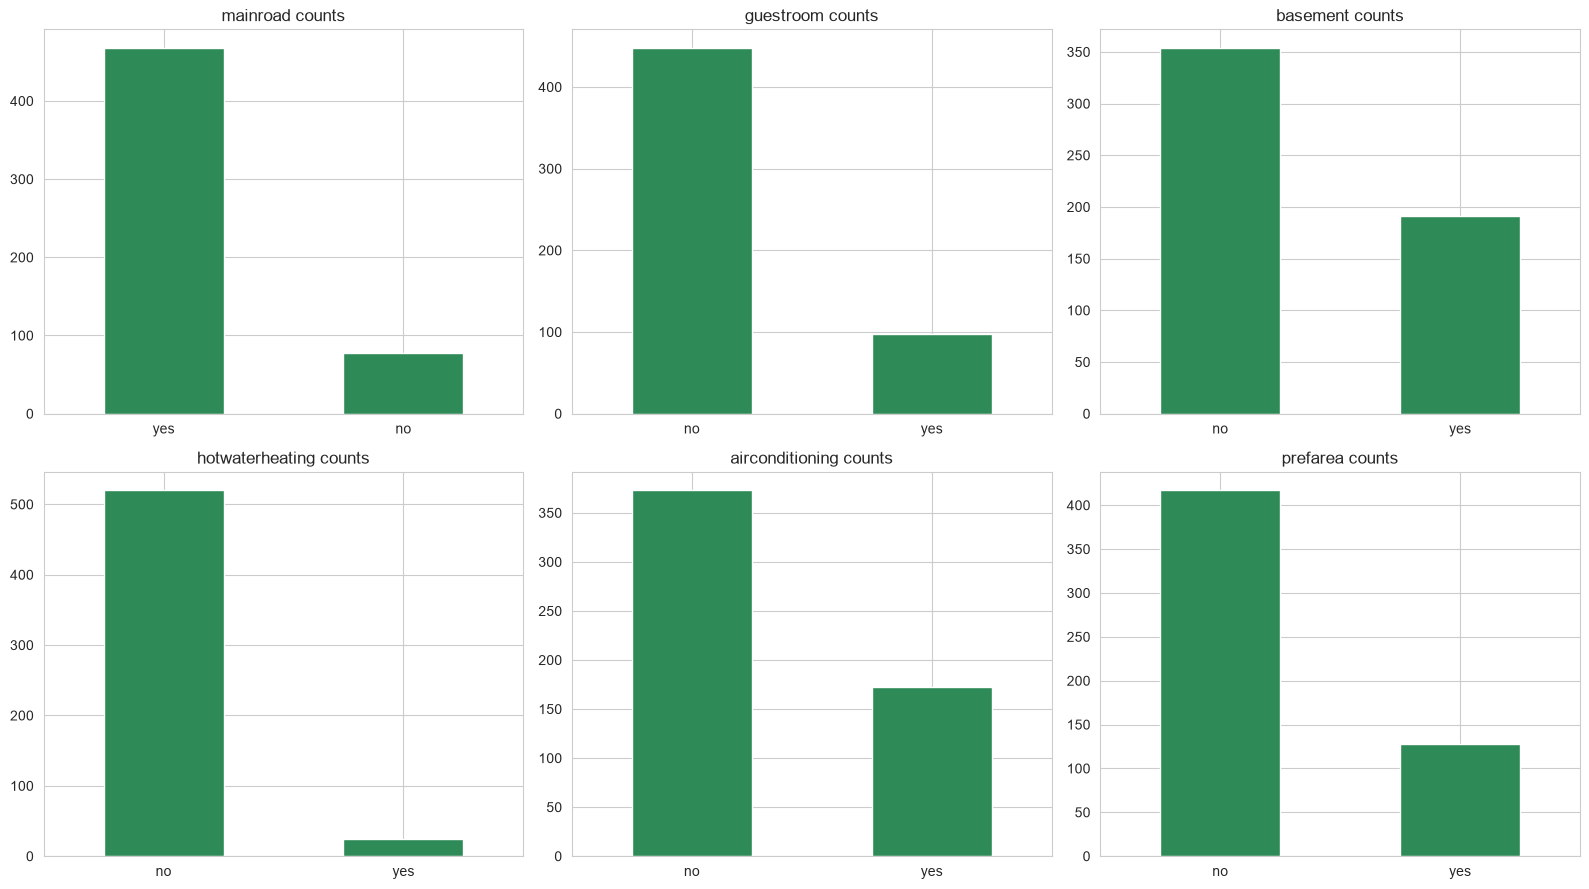

In [18]:
cat_cols_binary = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols_binary):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='seagreen')
    axes[i].set_title(f'{col} counts')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('univariate_categorical.png', dpi=120)
plt.show()


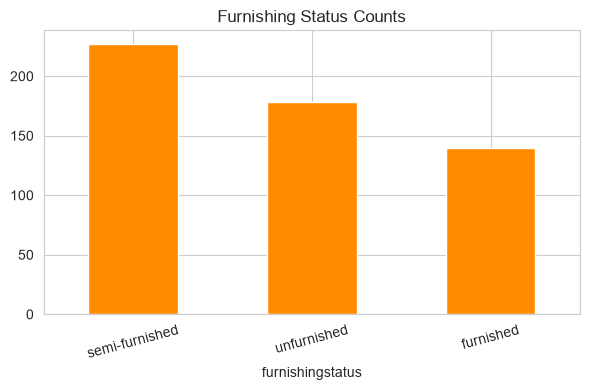

In [20]:
plt.figure(figsize=(6,4))
df['furnishingstatus'].value_counts().plot(kind='bar', color='darkorange')
plt.title('Furnishing Status Counts')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('univariate_furnishing.png', dpi=120)
plt.show()


In [17]:
print("Price summary statistics:")
print(df['price'].describe())
print(f"\nSkewness of price: {df['price'].skew():.2f}")
print(f"Skewness of area: {df['area'].skew():.2f}")


Price summary statistics:
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

Skewness of price: 1.21
Skewness of area: 1.32


**Observations so far:**
- `price` and `area` are right-skewed (a long tail of larger/pricier homes) — common in housing data.
- Most homes have 2–3 bedrooms, 1–2 bathrooms, and 1–2 stories.
- Binary amenities like `hotwaterheating` and `basement` are minority classes (few "yes"), while `mainroad` is dominated by "yes".


## 4. Bivariate Analysis

How each feature relates to `price`.

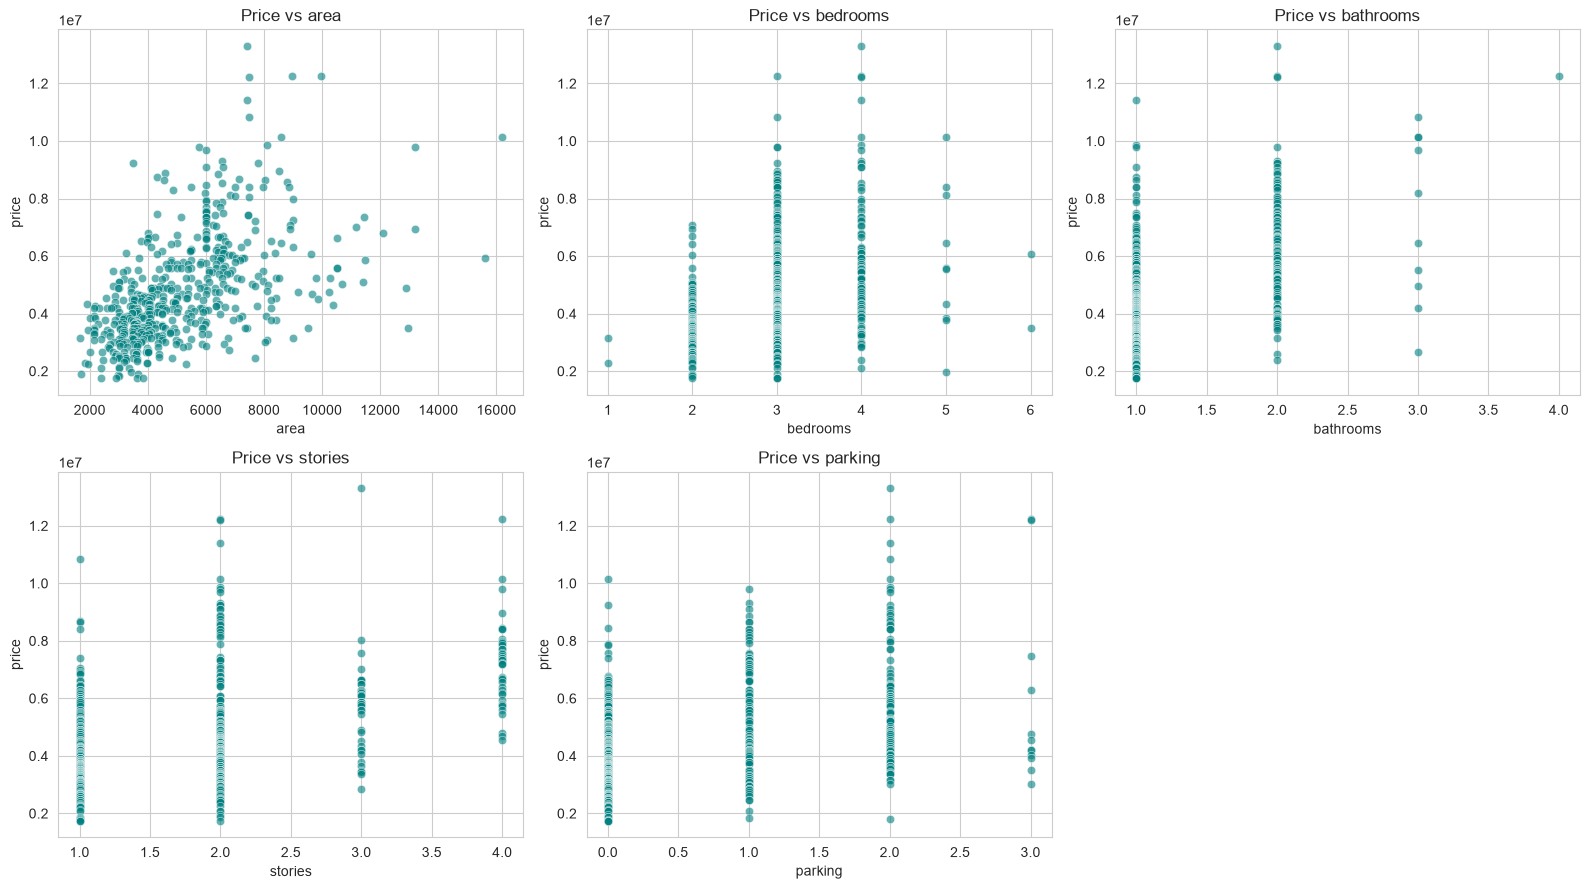

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
numeric_vs_price = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for i, col in enumerate(numeric_vs_price):
    sns.scatterplot(x=df[col], y=df['price'], ax=axes[i], alpha=0.6, color='teal')
    axes[i].set_title(f'Price vs {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('bivariate_scatter.png', dpi=120)
plt.show()

C:\Users\Student\AppData\Local\Temp\ipykernel_14512\3296240746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], ax=axes[i], palette='Set2')
C:\Users\Student\AppData\Local\Temp\ipykernel_14512\3296240746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], ax=axes[i], palette='Set2')
C:\Users\Student\AppData\Local\Temp\ipykernel_14512\3296240746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], ax=axes[i], palette='Set2')
C:\Users\Student\AppData\Local\Temp\ipyk

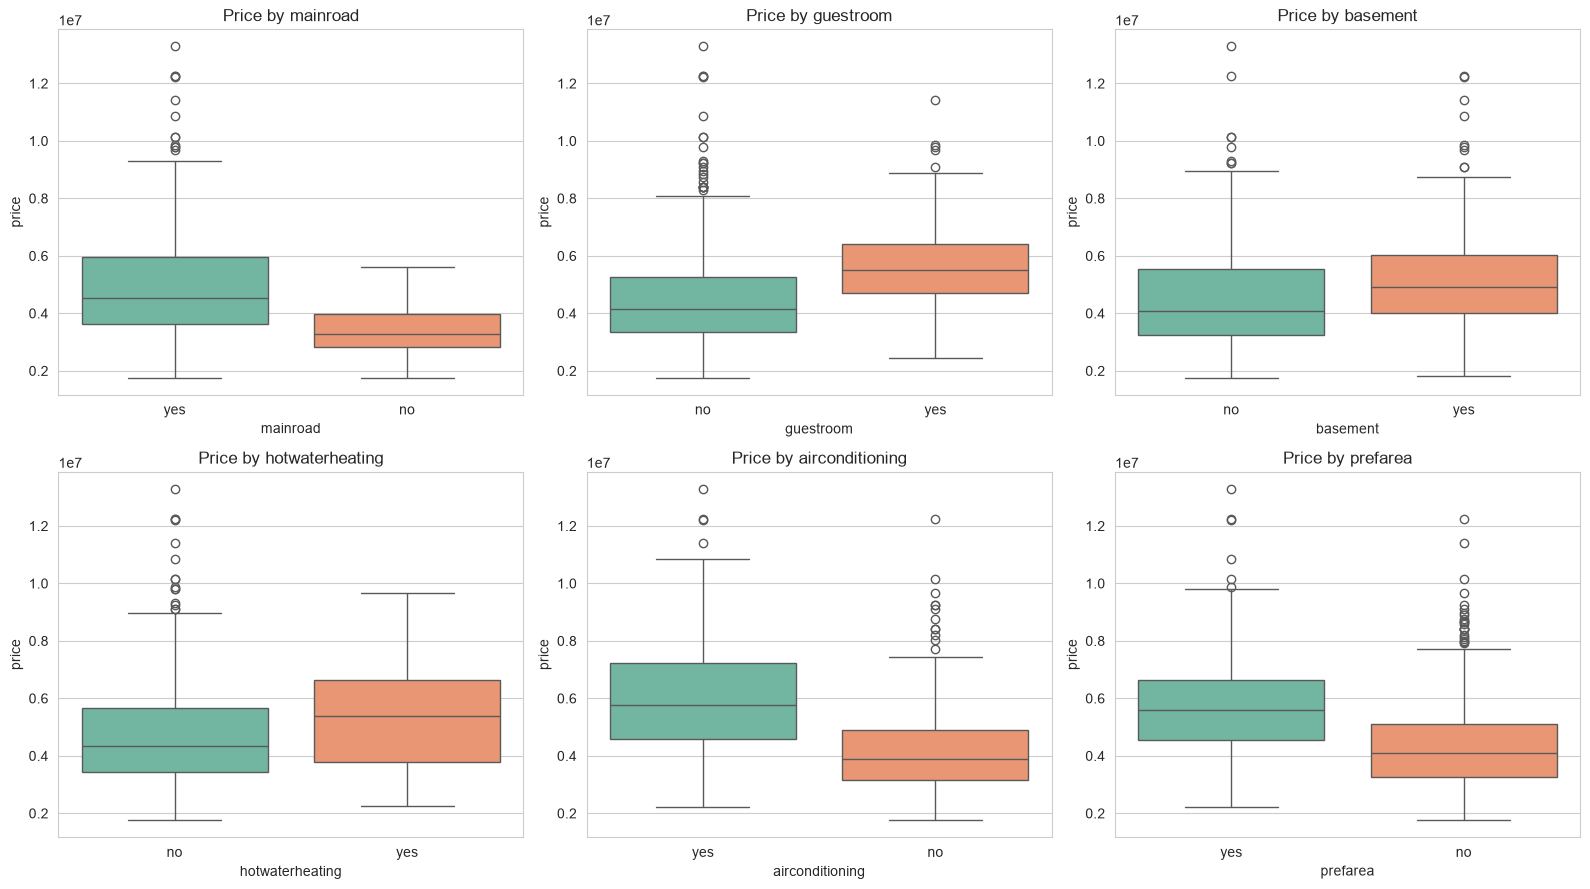

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols_binary):
    sns.boxplot(x=df[col], y=df['price'], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Price by {col}')
plt.tight_layout()
plt.savefig('bivariate_boxplots_categorical.png', dpi=120)
plt.show()


C:\Users\Student\AppData\Local\Temp\ipykernel_2960\2665476169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='furnishingstatus', y='price', data=df, palette='Set3')


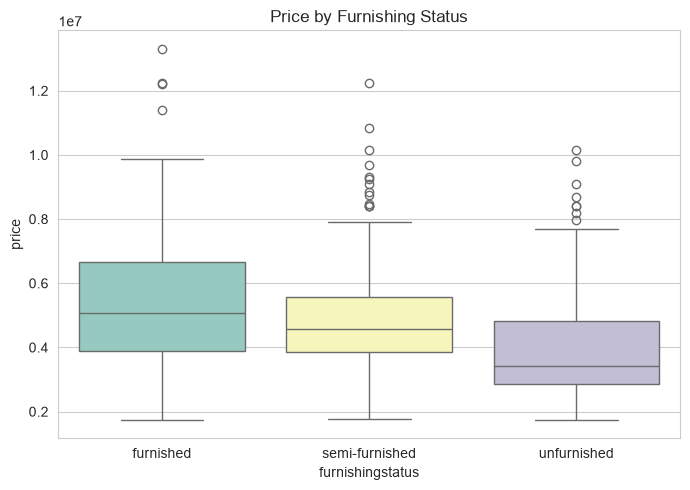

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='furnishingstatus', y='price', data=df, palette='Set3')
plt.title('Price by Furnishing Status')
plt.tight_layout()
plt.savefig('bivariate_furnishing.png', dpi=120)
plt.show()


In [23]:
# Average price by number of bedrooms / bathrooms / stories
for col in ['bedrooms', 'bathrooms', 'stories']:
    print(f"\nAverage price by {col}:")
    print(df.groupby(col)['price'].mean().round(0))



Average price by bedrooms:
bedrooms
1    2712500.0
2    3632022.0
3    4954598.0
4    5729758.0
5    5819800.0
6    4791500.0
Name: price, dtype: float64

Average price by bathrooms:
bathrooms
1     4206913.0
2     6209206.0
3     7282100.0
4    12250000.0
Name: price, dtype: float64

Average price by stories:
stories
1    4170659.0
2    4764074.0
3    5685436.0
4    7208450.0
Name: price, dtype: float64


**Observations:**
- `area` shows the clearest positive relationship with `price` — larger homes cost more, though with increasing spread at the high end.
- Homes with more bathrooms, more stories, and more parking spots tend to command higher prices.
- Binary amenities (`airconditioning`, `prefarea`, `hotwaterheating`, `basement`, `guestroom`, `mainroad`) are all associated with a visible price premium when present.
- Furnished homes tend to have a higher median price than semi-furnished or unfurnished homes.

## 5. Correlation & Feature Importance

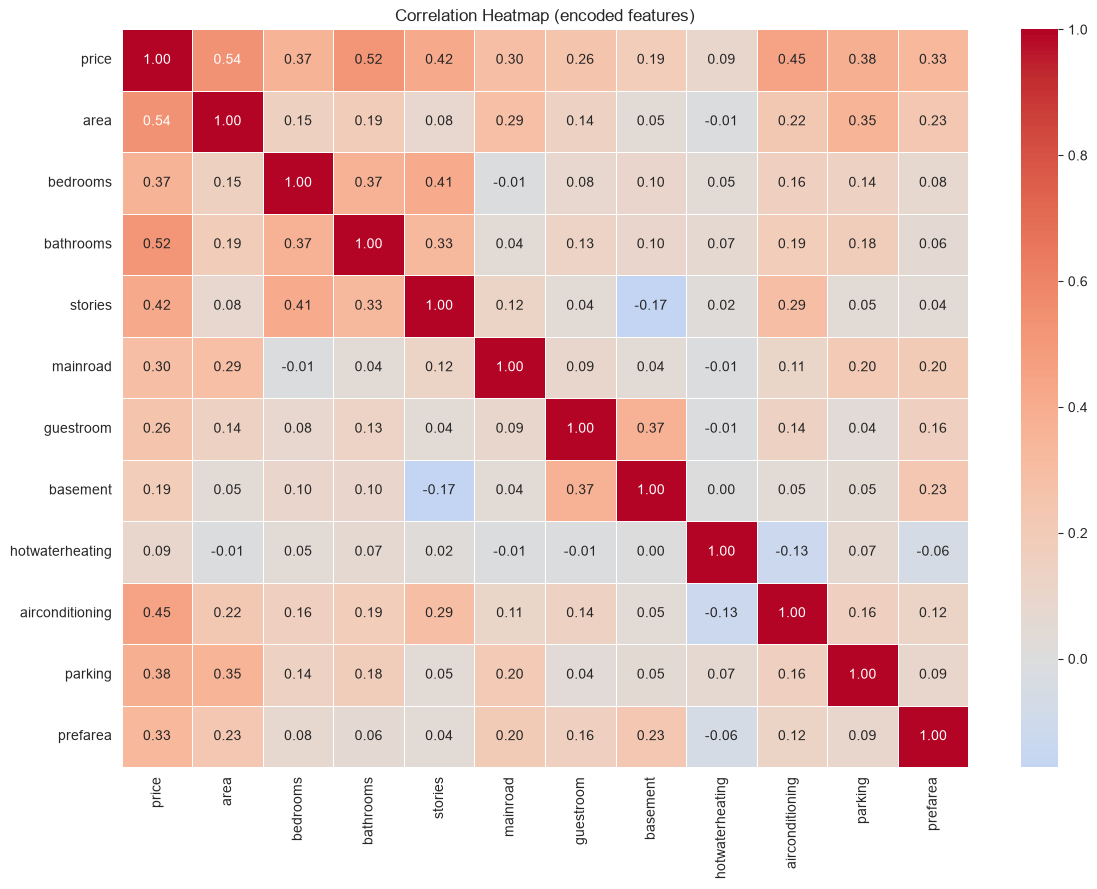

In [24]:
corr = df_encoded.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (encoded features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


Features ranked by absolute correlation with price:

area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
mainroad           0.296898
guestroom          0.255517
basement           0.187057
hotwaterheating    0.093073
Name: price, dtype: float64


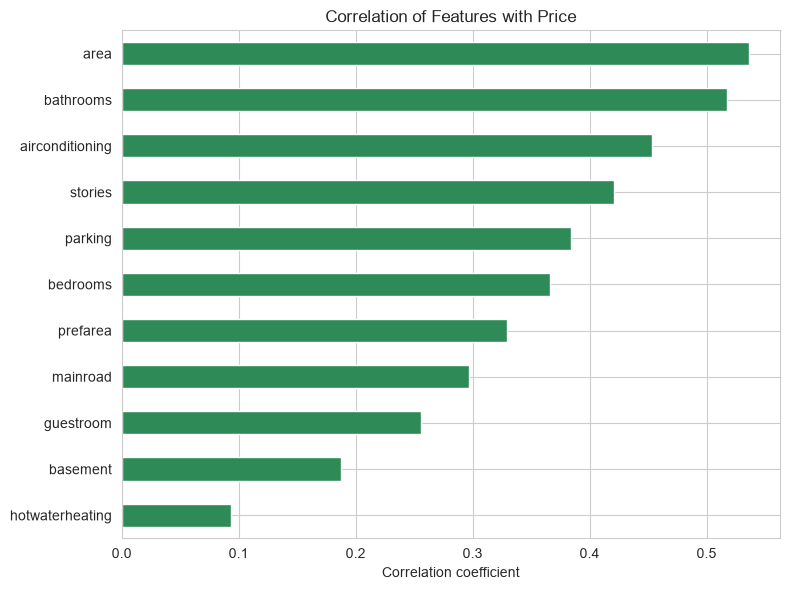

In [25]:
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with price:\n")
print(price_corr)

plt.figure(figsize=(8,6))
price_corr.plot(kind='barh', color=price_corr.apply(lambda x: 'seagreen' if x > 0 else 'indianred'))
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_correlation_with_price.png', dpi=120)
plt.show()


Random Forest feature importances:

area                               0.468127
bathrooms                          0.153039
airconditioning                    0.058369
parking                            0.056456
stories                            0.055122
bedrooms                           0.045857
furnishingstatus_unfurnished       0.034912
basement                           0.033091
prefarea                           0.028281
hotwaterheating                    0.017787
guestroom                          0.017775
furnishingstatus_furnished         0.011475
furnishingstatus_semi-furnished    0.010284
mainroad                           0.009426
dtype: float64


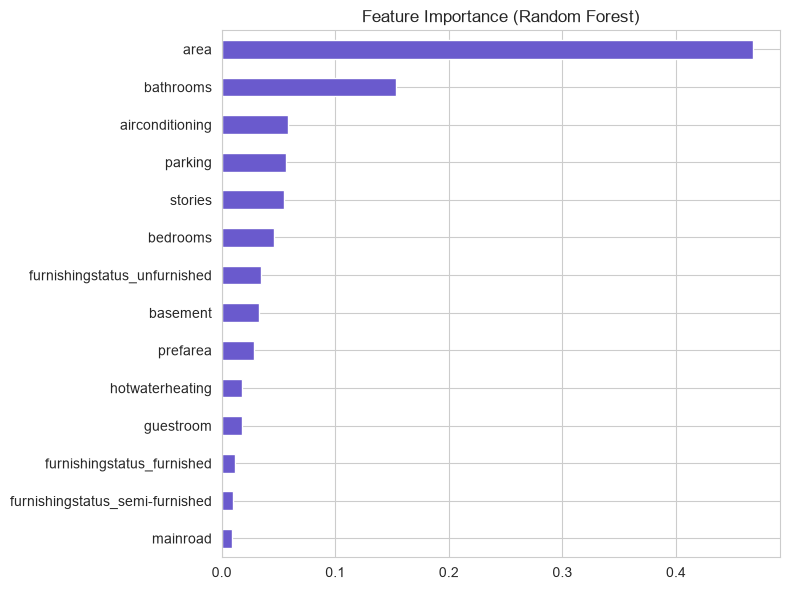


Model R^2 on test set: 0.620


In [26]:
# Feature importance via a quick Random Forest (complements correlation, captures non-linear effects)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest feature importances:\n")
print(importances)

plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='slateblue')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=120)
plt.show()

print(f"\nModel R^2 on test set: {rf.score(X_test, y_test):.3f}")


## 6. Key Insights Summary

### What drives price
Combining correlation analysis and Random Forest feature importance, consistently:
1. **`area`** is by far the strongest driver of price (correlation ≈ 0.54; ~47% of Random Forest importance) — the clearest, most consistent relationship in the dataset.
2. **`bathrooms`** is the next strongest predictor (correlation ≈ 0.52; ~15% of RF importance) — more bathrooms tracks closely with higher price.
3. **`airconditioning`**, **`stories`**, and **`parking`** follow — each shows a moderate positive correlation (0.38–0.45) and a smaller but real contribution to the model.
4. **`bedrooms`**, **`prefarea`** (preferred/desirable location), and **`mainroad`** access contribute smaller, positive effects.
5. **`furnishingstatus`**, `guestroom`, `basement`, and `hotwaterheating` have the weakest individual effects, though furnishing status still shows up as a visible price premium for furnished vs. unfurnished homes.

A Random Forest model using all features explains about **62% of the variance in price (R² ≈ 0.62)** on held-out data — solid for a small dataset with only structural/amenity features and no location or market data.
